---
title: "6. Time and rhythm"
subtitle: "The structure, perception, and performance of musical time"
---


Music unfolds in time. Rhythm and metre depend on duration, order, and recurrence. They give us the structures we use to predict, move, and coordinate. The chapter begins with broad ideas of time and rhythm, then turns to timing, the question of when a single sound happens. From there it turns to pulse and tempo, to entrainment as the mechanism that lets us move to a beat, and to metre as the hierarchy that entrainment builds. We then zoom in on microrhythmic nuance and end with the phenomenon of groove. This chapter runs across all the [four levels of description](#levels-of-description). An onset is a *physical* event you can find in a waveform; a perceptual centre is where the ear puts it; a backbeat that feels laid-back rather than late is *interpretation*. Here, we will explore how they compare.

## Time

Time in music refers to the organisation of sounds and silences in a temporal framework. It is the foundation on which rhythm, beat, and metre are built. Musical time is also more than clock measurement: it is shaped by perception, culture, and performance practice. Rhythms and metres may be notated in a score, but their feel depends on how musicians and listeners interpret and embody them.


```{exercise} Start here: your spontaneous tempo
:label: exercise-spontaneous-tempo

Do this before reading further, on your own, with the [Spontaneous tempo](https://fourms.github.io/sensingsoundandmusic/apps/spontaneous-tempo/) app.

- Choose blind mode and 20 s. Press Start, then tap at whatever rate feels natural, with no music playing, until the end beep. The page shows nothing while you tap.
- Note the tempo in BPM and the standard deviation of the intervals.
- Repeat later in the day, and the next day if you can, and compare the runs in the app's table.
- Then try live mode once and watch the interval plot while you tap.

Reflect: Did your rate stay the same between runs? Did seeing the plot change how you tapped? Your rate is your *spontaneous motor tempo*, which is treated in the section on pulse and tempo later in this chapter.
```

### Time scales

Sound and music span a range of time scales, and different scales are handled by different parts of the hearing system and the brain. The figure below lays them out on a logarithmic axis, where each step is ten times longer than the last. At the fast end sit differences of a few tens of microseconds between the two ears, which the auditory system uses to locate a sound source (see [psychoacoustics](psychoacoustics.ipynb)). Waveform periods between about 0.05 and 50 ms are heard as pitch rather than as separate events. After that, we start hearing individual events, and rhythmic structures may emerge.

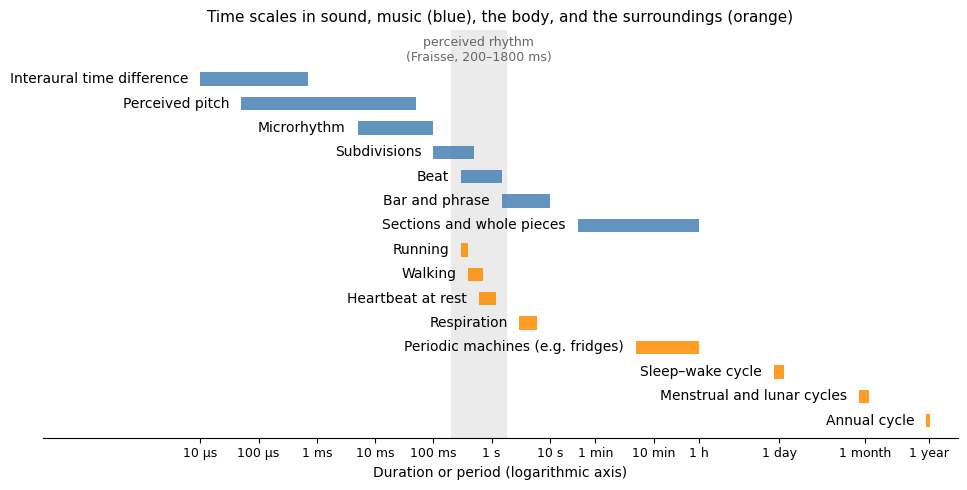

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Approximate ranges, in seconds, for illustration only.
music = [
    ("Interaural time difference", 1e-5, 7e-4),
    ("Perceived pitch", 5e-5, 5e-2),
    ("Microrhythm", 5e-3, 1e-1),
    ("Subdivisions", 1e-1, 5e-1),
    ("Beat", 3e-1, 1.5),
    ("Bar and phrase", 1.5, 10),
    ("Sections and whole pieces", 30, 3600),
]
body = [
    ("Running", 0.3, 0.4),
    ("Walking", 0.4, 0.7),
    ("Heartbeat at rest", 0.6, 1.2),
    ("Respiration", 3, 6),
    ("Periodic machines (e.g. fridges)", 300, 3600),
    ("Sleep\u2013wake cycle", 7e4, 1.05e5),
    ("Menstrual and lunar cycles", 2.0e6, 3.0e6),
    ("Annual cycle", 2.9e7, 3.4e7),
]
rows = [(n, lo, hi, "steelblue") for n, lo, hi in music] + \
       [(n, lo, hi, "darkorange") for n, lo, hi in body]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(0.2, 1.8, color="0.92", zorder=0)
ax.text(np.sqrt(0.2 * 1.8), len(rows) - 0.4, "perceived rhythm\n(Fraisse, 200\u20131800 ms)",
        ha="center", va="bottom", color="0.4", fontsize=9)
for i, (name, lo, hi, col) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.barh(y, hi - lo, left=lo, height=0.55, color=col, alpha=0.85, zorder=3)
    ax.text(lo / 1.6, y, name, ha="right", va="center")
ax.set_xscale("log")
ticks = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 60, 600, 3600, 86400, 2.6e6, 3.15e7]
labels = ["10 \u00b5s", "100 \u00b5s", "1 ms", "10 ms", "100 ms", "1 s", "10 s",
          "1 min", "10 min", "1 h", "1 day", "1 month", "1 year"]
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_xlim(2e-8, 1e8)
ax.set_ylim(-0.7, len(rows) + 1.0)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("Duration or period (logarithmic axis)")
ax.set_title("Time scales in sound, music (blue), the body, and the surroundings (orange)")
plt.tight_layout()
plt.show()


*Figure: Time scales of sound and music (blue) and of the body and its surroundings (orange) on a logarithmic axis. The grey band marks the range in which Fraisse placed perceived rhythm. The ranges are approximate and drawn for orientation, not measured.*

The psychologist [Paul Fraisse](https://en.wikipedia.org/wiki/Paul_Fraisse) distinguished between rhythms that are *perceived* and rhythms that are *conceived* {cite:p}`Fraisse1982`. Perceived rhythms have intervals of roughly 200–1800 ms, which is the range of subdivisions, beats, and short groupings. Faster events fuse into a single sound: you can hear this happen with the [From pulse to pitch](https://fourms.github.io/sensingsoundandmusic/apps/pulse-to-pitch/) app, where a click repeated faster and faster turns from a series of pulses into a buzzing tone once the gaps are shorter than a few tens of milliseconds. Slower cycles have to be counted or remembered rather than felt. The upper limit is related to the few seconds that auditory short-term memory can hold at once, which is also about the length of a musical phrase.

:::{note} Dig deeper: the layers of memory
:class: dropdown
Bob Snyder separates memory into layers that line up with the scales in the figure {cite:p}`Snyder2000`:

- **[Echoic memory](https://en.wikipedia.org/wiki/Echoic_memory)** holds the raw sound for a fraction of a second. It is what fuses fast events into a single tone with a pitch, and it is where the ear decides when an attack begins.
- **[Short-term memory](https://en.wikipedia.org/wiki/Short-term_memory)** holds about 3–5 s, a little more with rehearsal, and only about seven items at a time, the "[magical number seven](https://en.wikipedia.org/wiki/Miller%27s_law), plus or minus two" {cite:p}`Miller1956`. This is the span of a phrase and of a metric cycle, and the reason a rhythm has to repeat within a few seconds to be felt rather than counted.
- **[Working memory](https://en.wikipedia.org/wiki/Working_memory)** is the active part of short-term memory: counting beats, holding the pattern of one bar while playing the next, comparing a repetition with the one before.
- **[Long-term memory](https://en.wikipedia.org/wiki/Long-term_memory)** holds minutes to years: the form of a piece, the metres and grooves of a style learned over a lifetime, and the expectations a listener brings before the first note. Slower cycles are conceived here rather than perceived.

Snyder ties these layers to three levels of musical experience: event fusion, melodic and rhythmic grouping, and form. Most of this chapter lives in the middle level.
:::
The body keeps time at several of these scales too. Walking steps come about twice a second and running steps about three times a second, the heart beats about once a second at rest, and a breath takes around four seconds. Slower still are the cycles that [chronobiology](https://en.wikipedia.org/wiki/Chronobiology) studies {cite:p}`Koukkari2006`: hormonal rhythms of an hour or two, the 24-hour [sleep–wake cycle](https://en.wikipedia.org/wiki/Circadian_rhythm), the [menstrual cycle](https://en.wikipedia.org/wiki/Menstrual_cycle) of about a month, close to the [lunar cycle](https://en.wikipedia.org/wiki/Lunar_phase), and the annual cycle of the seasons that governs migration and hibernation. None of these are perceived as rhythms in Fraisse's sense, but they form the background against which musical time is experienced, and they can couple to music, as the sections on entrainment below and the chapter on [physiology](physiology.ipynb) show. At the slow end of the axis, the appliances in a room switch on and off with periods of minutes, a case we return to at the end of the chapter.

### Clock time and felt time

A clock measures duration; a listener feels it. Psychologists separate judgements of *duration*, how long something lasted, from judgements of the *[passage of time](https://en.wikipedia.org/wiki/Time_perception)*, whether it seemed to pass quickly or slowly {cite:p}`Wearden2015`. The two do not always agree. A three-minute song and three minutes of silence have the same duration, but they are not felt to be the same length, and a long concert can pass in a flash while a short wait feels endless. The classic explanation is an internal clock whose ticks are counted and compared with memory, so that a faster clock, driven by arousal or attention, makes an interval feel longer {cite:p}`Allman2014`. More recent accounts suggest that the brain keeps several parallel timelines that are recalibrated as events unfold rather than one central clock.

```{exercise} How long is 3 minutes?
:label: exercise-3-minute-standstill

Turn on a stopwatch. Stand still. Try to stand for exactly 3 minutes. Check the timer when you are done. How long did you stand? How did it feel?
```


## Rhythm

What is rhythm? Everyone knows one when they hear it, yet the word is hard to pin down. At its most general, [rhythm](https://en.wikipedia.org/wiki/Rhythm) is about repetition. In biology it has been defined as "a change that is repeated with a similar pattern" {cite:p}`Koukkari2006`, and Anne Danielsen, borrowing a phrase from the poet [Amiri Baraka](https://en.wikipedia.org/wiki/Amiri_Baraka), describes musical rhythm as a "changing same" {cite:p}`Danielsen2010`. Both definitions include the heartbeat, the tides, and a fridge switching on and off, and this chapter uses rhythm in that broad sense whenever it looks beyond music.

In music the term usually means something narrower: a *pattern of durations formed by the intervals between the perceived time points of notes*. Notice the word *perceived*. A rhythm is not the sound signal itself but the pattern of time points a listener hears in it. This is why the same recording can be heard as several rhythms, and why the perceptual centre of a sound, discussed later in this chapter, matters as much as its physical onset.

### Rhythm in notation

Western notation writes such patterns of durations with *note values*. Each value is half the length of the one before it, from the whole note down through half, quarter, eighth, and sixteenth notes, and every value has a rest of the same length for silence. A dot extends a value by half, and a tuplet squeezes three notes into the time of two. Note values say nothing about how long a note lasts in seconds; that is fixed only when a tempo is chosen.

```{image} figures/time-and-rhythm/notation/note-values.svg
:alt: A rhythm tree of note values from whole to sixteenth, one row per value with the matching rests beside, and a final row with a dotted quarter and a triplet
:width: 100%
```

*Figure: Note values and rests in Western notation. Each row fills one bar of 4/4 with twice as many notes as the row above, so the halving lines up vertically, and the second bar of each row shows the rest of the same length. The last row shows a dotted quarter and a triplet.*

### Periodic and aperiodic rhythms

Rhythms can be *periodic* (based on cycles, such as a metronome) or *aperiodic* (irregular, as in speech or improvisation). Both can be meaningful: a drum groove in 4/4 and a free jazz solo each have rhythm, but in different senses.

Rhythms also carry cultural meaning. A [clave](https://en.wikipedia.org/wiki/Clave_(rhythm)) rhythm in Afro-Cuban music is more than a sequence of durations; it is a structural reference for musicians and dancers. In the same way, speech rhythms shape the flow of rap and spoken-word performance.

### Rhythm as a signal

Rhythms are often drawn as points on a timeline, but both bodily and musical rhythms are carried by continuous signals that can vary in the three ways we discussed in the acoustics chapter:  *period* (time taken by one cycle), *amplitude* (strength of each cycle), and its *phase* (the position within the cycle at a given moment). All three return later in the chapter: the period sets the tempo, differences in amplitude mark the accents of a metre, and phase is what a tapping finger aligns when it entrains to a beat.

"Perfect" rhythms are rare. A [metronome](https://en.wikipedia.org/wiki/Metronome) comes close, but few people would call a metronome musical. What makes music interesting is that its rhythms are not perfect. Much of the research presented in this chapter, from tapping to swing, is about how much, and in what way, real rhythms depart from perfect ones.

### Rhythm and movement

Rhythm is also tied to movement. Eric Clarke argues that rhythm and timing can be "seen as the consequence of movement, and rhythm and timing seen as the source of, or motivation for, movement" {cite:p}`Clarke1999`. That two-way link between hearing a rhythm and moving to it runs through the sections on tempo, entrainment, and groove.

## Timing

In rhythm studies, it is crucial to say *when* a sound happens. This is a much harder question than it sounds. A sound has a physical onset that can be found in the waveform, a moment at which the ear places it, and several landmarks in between. The distance between these is small, often a few tens of milliseconds, but it is the same size as the timing differences that give music its feel, so it has to be sorted out first.

### Onset timing

When we speak of the "timing" of instruments in performance, we usually mean *[onset](https://en.wikipedia.org/wiki/Onset_(audio)) timing*: when each sound begins. In a recording, the *physical onset* is the moment the waveform starts to rise out of the silence or the background. Finding it automatically is a standard task in audio analysis, and the algorithms for it are treated in [machine listening](machine-listening.ipynb). A sound has other timing landmarks too:

- **Physical onset**: the moment the sound begins in the waveform
- **Energy peak**: the moment the sound is loudest
- **Attack time**: the time from the physical onset to the energy peak
- **Perceptual centre**: the moment the ear places the sound at, which is the subject of the next section

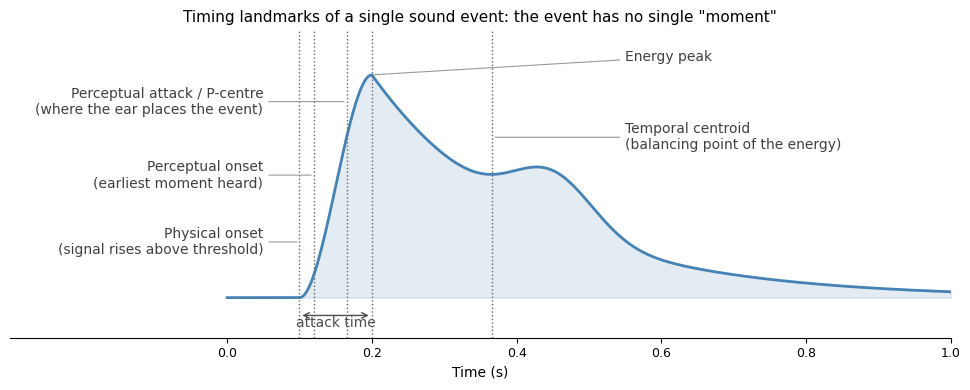

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

t = np.linspace(0, 1.0, 2000)
onset = 0.10
rise = np.clip((t - onset) / 0.10, 0, 1)
attack = rise ** 2 * (3 - 2 * rise)                          # smooth rise from onset to peak
decay = np.exp(-(t - 0.20) / 0.22) * (t >= 0.20) + (t < 0.20)
shoulder = 0.25 * np.exp(-((t - 0.45) / 0.08) ** 2)         # a second bump, as in a real tone
env = attack * decay + shoulder * (t > 0.2)
env /= env.max()

t_peak = t[np.argmax(env)]
t_centroid = np.sum(t * env) / np.sum(env)
t_perc_onset = onset + 0.02
t_perc_attack = onset + 0.065

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(t, env, color="steelblue", alpha=0.15)
ax.plot(t, env, color="steelblue", linewidth=2)
marks = [
    (onset, "Physical onset\n(signal rises above threshold)", 0.05, 0.25),
    (t_perc_onset, "Perceptual onset\n(earliest moment heard)", 0.05, 0.55),
    (t_perc_attack, "Perceptual attack / P-centre\n(where the ear places the event)", 0.05, 0.88),
    (t_peak, "Energy peak", 0.55, 1.08),
    (t_centroid, "Temporal centroid\n(balancing point of the energy)", 0.55, 0.72),
]
for x, label, tx, ty in marks:
    ax.axvline(x, color="0.4", linestyle=":", linewidth=1)
    ax.annotate(label, xy=(x, min(ty, 1.0)), xytext=(tx, ty),
                ha="right" if tx < x else "left", va="center", color="0.25",
                arrowprops=dict(arrowstyle="-", color="0.6", linewidth=0.8))
ax.annotate("", xy=(onset, -0.08), xytext=(t_peak, -0.08),
            arrowprops=dict(arrowstyle="<->", color="0.3"))
ax.text((onset + t_peak) / 2, -0.13, "attack time", ha="center", color="0.3")
ax.set_xlim(-0.3, 1.0)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_ylim(-0.18, 1.2)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("Time (s)")
ax.set_title("Timing landmarks of a single sound event: the event has no single \"moment\"")
plt.tight_layout()
plt.show()


*Figure: The amplitude envelope of one tone with the timing landmarks used in rhythm research. Schematic, after {cite:t}`Nymoen2017`.*

### Perceptual centre and attack time

When listening to rhythms, the "moment of occurrence" of a sound, the point we use to place it in time, often does not coincide with its physical onset. This percept is usually called the *perceptual centre* (P-centre) or *perceived attack time* (PAT): a subjective reference point that typically falls somewhere after the physical onset and before the peak of the sound's energy. 

Studies show that certain sound parameters affect where P-centres are heard. Attack duration or time (from onset to peak) is the strongest factor: *faster attacks* yield *earlier* P-centres, and *slower attacks* yield *later* ones. Total duration (from onset to offset) has a weaker but similar influence, with shorter sounds shifting P-centres earlier and longer sounds shifting them later. A RITMO study that varied the attack, duration, and frequency of drum sounds and synthetic tones confirmed this pattern, and also found that slow-attack sounds have a wider, less precise P-centre {cite:p}`Danielsen2019`. Anne Danielsen describes the consequence as a *beat bin*: the beat is not a point in time but a window, and the sounds that mark it decide how wide the window is.

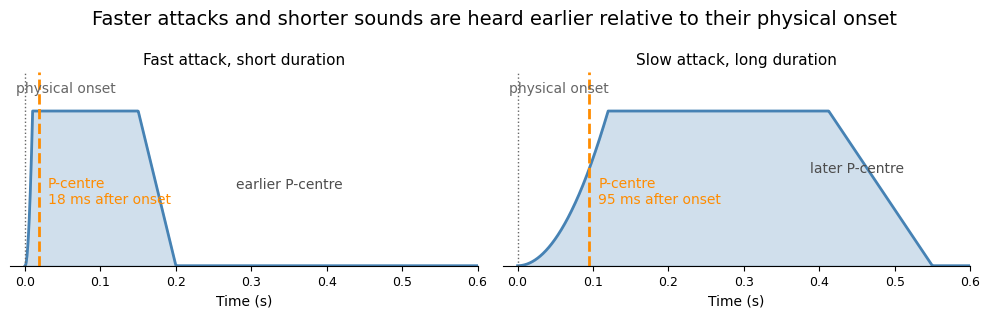

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

t = np.linspace(0, 0.6, 1200)

def envelope(attack, duration):
    rise = np.clip(t / attack, 0, 1) ** 2
    fall = np.clip((duration - t) / (0.25 * duration), 0, 1)
    return rise * fall

cases = [
    ("Fast attack, short duration", 0.01, 0.20, 0.018),
    ("Slow attack, long duration", 0.12, 0.55, 0.095),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (name, attack, duration, pcentre) in zip(axes, cases):
    env = envelope(attack, duration)
    ax.fill_between(t, env, color="steelblue", alpha=0.25)
    ax.plot(t, env, color="steelblue", linewidth=2)
    ax.axvline(0, color="0.4", linestyle=":", linewidth=1)
    ax.axvline(pcentre, color="darkorange", linestyle="--", linewidth=2)
    ax.text(-0.012, 1.12, "physical onset", color="0.4")
    ax.text(pcentre + 0.012, 0.4, f"P-centre\n{pcentre * 1000:.0f} ms after onset", color="darkorange")
    ax.set_title(name)
    ax.set_xlim(-0.02, 0.6)
    ax.set_ylim(0, 1.25)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_xlabel("Time (s)")
axes[0].text(0.35, 0.5, "earlier P-centre", color="0.3", ha="center")
axes[1].text(0.45, 0.6, "later P-centre", color="0.3", ha="center")
plt.suptitle("Faster attacks and shorter sounds are heard earlier relative to their physical onset")
plt.tight_layout()
plt.show()


*Figure: Two sounds starting at the same instant. The ear places the sharp, short one almost at its onset and the slow, long one well after it. Schematic; the millisecond values are illustrative.*

### Timbre and timing

The P-centre results have a practical consequence: *what* plays affects *when* it is heard. Here, the *timbre* of the instruments (its sound "colour") is important. Because the P-centre depends on the attack, two musicians who want to sound together cannot simply start their notes at the same instant. A bassist with a soft, round attack has to play slightly ahead of a drummer's sharp snare stroke for the two to be heard as synchronous, and a choir, whose consonants take time to form, will sound behind a piano unless the singers anticipate. Producers meet the same problem from the other side: lining up tracks by their waveform onsets in a digital audio workstation does not guarantee that they sound "tight", so many align by ear instead. Timbre also decides how precisely timing can be judged at all.

Take two guitar chords, one played by slowly arpeggiating the strings ("*swept*") and one played by stroking all the strings in quick succession ("*swift*"). Although both come from the same instrument, the swept stroke tends to sound as if it occurs slightly later relative to its physical onset, while the swift stroke has a P-centre much closer to its onset timing.

```{image} figures/time-and-rhythm/week6_image15.png
:width: 100%
```

*Image source: adapted from* {cite:t}`Camara2020`.

The figure below shows the consequence for a sequence. Three identical sounds with evenly spaced onsets sound evenly spaced (A). Replace the middle one with a slow-attack sound and the onsets are still even, but its P-centre falls late, so the sequence sounds uneven (B). The same holds for sounds that start together: they sound together only if their P-centres coincide, not their onsets.

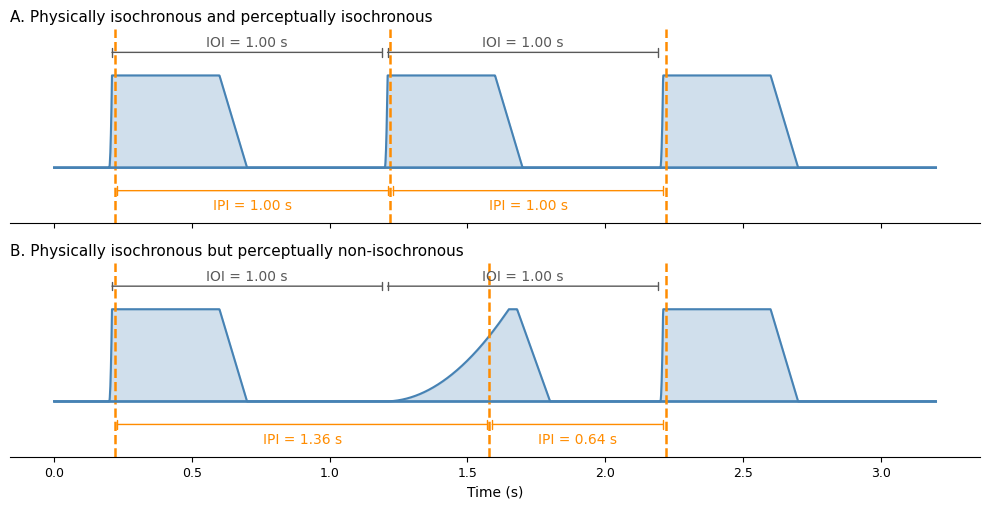

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

t = np.linspace(0, 3.2, 3200)

def envelope(start, attack, duration):
    x = t - start
    rise = np.clip(x / attack, 0, 1) ** 2
    fall = np.clip((duration - x) / (0.2 * duration), 0, 1)
    return rise * fall * (x >= 0)

onsets = [0.2, 1.2, 2.2]                                         # equal IOIs of 1.0 s
rows = [
    ("A. Physically isochronous and perceptually isochronous",
     [(0.01, 0.5, 0.02)] * 3),
    ("B. Physically isochronous but perceptually non-isochronous",
     [(0.01, 0.5, 0.02), (0.45, 0.6, 0.38), (0.01, 0.5, 0.02)]),
]
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
for ax, (title, sounds) in zip(axes, rows):
    pcentres = []
    for start, (attack, duration, offset) in zip(onsets, sounds):
        env = envelope(start, attack, duration)
        ax.fill_between(t, env, color="steelblue", alpha=0.25)
        ax.plot(t, env, color="steelblue", linewidth=1.5)
        ax.axvline(start + offset, color="darkorange", linestyle="--", linewidth=1.8)
        pcentres.append(start + offset)
    for k in range(2):                                            # IOI brackets above
        ax.annotate("", xy=(onsets[k], 1.25), xytext=(onsets[k + 1], 1.25),
                    arrowprops=dict(arrowstyle="|-|", color="0.35", mutation_scale=3))
        ax.text((onsets[k] + onsets[k + 1]) / 2, 1.32,
                f"IOI = {onsets[k + 1] - onsets[k]:.2f} s", ha="center", color="0.35")
        ax.annotate("", xy=(pcentres[k], -0.25), xytext=(pcentres[k + 1], -0.25),
                    arrowprops=dict(arrowstyle="|-|", color="darkorange", mutation_scale=3))
        ax.text((pcentres[k] + pcentres[k + 1]) / 2, -0.45,
                f"IPI = {pcentres[k + 1] - pcentres[k]:.2f} s", ha="center", color="darkorange")
    ax.set_title(title, loc="left")
    ax.set_ylim(-0.6, 1.5)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


*Figure: Three sounds with identical onset spacing. In A they also sound evenly spaced. In B the middle sound has a slow attack, its P-centre (dashed) falls late, and the sequence sounds uneven even though the onsets are not. Schematic, after {cite:t}`Villing2010`.*

### Space and timing

Recall from [acoustics](acoustics.ipynb) that sound travels at about 343 metres per second. Thus, two musicians 10 metres apart therefore hear each other about 30 ms late, which is more than the asynchronies that give a groove its feel. In a symphony orchestra the distance from the double basses to the first violins can exceed 20 metres, which is one reason players follow the conductor's visible beat rather than the sound from the far side of the stage. 

The same problem appears when musicians play together over a network. In experiments where two people clapped a rhythm together through an artificial delay, tempo stayed stable up to a delay of roughly 10 to 20 ms and then slowed steadily as the delay grew, because each player waited for the other {cite:p}`Chafe2010`. 

Rooms add an additional spatial effect. Reverberation prolongs every sound and smears the onsets that timing perception depends on, so fast, detailed rhythms that are crisp in a dry studio become a wash in a cathedral. Music written for reverberant spaces tends, accordingly, to move slowly.

```{admonition} Question
:class: question
Have you experienced timing problems in a large space or if you have tried to perform with someone over a networked connection?
```

## Pulse and tempo

With the timing of single sounds settled, we can turn to the regular series of them that a listener feels as a beat, to how fast it goes, and to the rate at which the body would set it on its own.

### Pulse

The *[beat](https://en.wikipedia.org/wiki/Beat_(music))* (also called the *tactus* or *[pulse](https://en.wikipedia.org/wiki/Pulse_(music))*) is the basic time unit of music: the regular series of moments that a listener feels the music moving in. A pulse can also describe an ongoing stream of beats; one can speak of 8th-note pulses just as much as quarter-note pulses. Either way, the beat level is what we naturally tap our feet to, giving stability and predictability to performers and listeners alike.

Research suggests that we comfortably perceive and move to beats when the time between them (the inter-onset interval, IOI) lies between about 500 and 700 ms, that is, 86–120 BPM. Pulse is thus closely tied to our sensorimotor system: we tend to move along with it. Faster events are heard as subdivisions, and slower ones are grouped into larger spans.

Note that in music, the pulse is not always marked by sound. Even when silent, it can be inferred as a virtual reference that organises events. Musicians often "feel" the pulse even when they play around it.

You can explore this with the [Silent beats](https://fourms.github.io/sensingsoundandmusic/apps/silent-beats/) app, which loops one bar of 4/4 with a pulse of four clicks and a rhythm on a grid of sixteenths. Any click or event can be silenced, the pulse can drop out for whole bars, and the rhythm can be rotated against the beat, so that the same durations fall on different levels of the metric hierarchy.

```{exercise} Optional: a pulse that is not played
:label: exercise-silent-beats

Open the [Silent beats](https://fourms.github.io/sensingsoundandmusic/apps/silent-beats/) app and press Start.

- Play "Off-beats only" with the pulse in every bar, then set the pulse to never. Where is beat 1 now? Does it stay where it was?
- Choose the tresillo and let the pulse drop out for 3 bars at a time. When the clicks return, do they land where you expected?
- Rotate the tresillo one sixteenth at a time. At which positions does it still feel like the same rhythm, and where does it turn into something else?
- Silence beats 2, 3, and 4 of the pulse, keep beat 1, and slow the tempo. How slow can you go before you lose the beats in between?

Reflect: What information do you use to keep the pulse when nothing marks it? What would you need to add to the rhythm track to make the pulse ambiguous?
```

### Tempo

[Tempo](https://en.wikipedia.org/wiki/Tempo) is the rate of the beat, measured in beats per minute (BPM). In notation the beat is often the quarter note, but the tempo is a property of what is heard, not of how it is written. 

Western scores have marked tempo in two ways. Since the early 1800s a *metronome marking* such as ♩ = 120 has given the beat rate exactly, in beats per minute, a practice that spread with Maelzel's clockwork [metronome](https://en.wikipedia.org/wiki/Metronome) and that Beethoven took up at once. Older, and still more common, are the Italian *tempo markings*, which name a character as much as a speed. The table gives the conventional ranges printed on metronomes; they vary between sources and periods, and a marking such as *andante*, from the Italian for walking, says how the music should move rather than exactly how fast.

| Marking | Meaning | Conventional range (BPM) |
|---|---|---:|
| Largo | broad | 40–60 |
| Adagio | at ease | 66–76 |
| Andante | walking | 76–108 |
| Moderato | moderate | 108–120 |
| Allegro | lively | 120–156 |
| Vivace | brisk | 156–176 |
| Presto | very fast | 168–200 |

Two further markings change tempo within a piece: *accelerando* and *ritardando* for a gradual speeding up or slowing down, and *rubato*, literally stolen time, for the performer's freedom to stretch and compress the beat expressively. All of these describe the beat level; the subdivisions and bars scale with it.


### Spontaneous motor tempo

Recall the exercise at the beginning of this chapter. When done in controlled studies, most people will settle at around 100–120 BPM, an interval of roughly 500–600 ms between taps. This rate is called the *spontaneous motor tempo* (SMT) {cite:p}`Fraisse1982`. It varies between people, is fairly stable within a person from day to day, and slows with age. 

The spontaneous motor tempo also matches the rate of walking, and sits close to the tempo at which people most easily hear and follow a beat, which peaks at around 120 BPM {cite:p}`Moelants2002`. Much dance music lives in the same range, or a little faster, to "make" you move. 

The overlap between tapping, walking, and preferred musical tempo is one of the clearest signs that musical time is rooted in the moving body. Tapping is also the standard laboratory task for studying timing: in *sensorimotor synchronisation* experiments, people tap along with a metronome and the timing of each tap is measured against the click {cite:p}`Repp2005`. How the body produces timing, from tapping to whole-body movement, is the subject of a section in [the body](the-body.ipynb).


## Entrainment

[Entrainment](https://en.wikipedia.org/wiki/Entrainment_(biomusicology)) refers to the synchronisation of a person's movements or internal rhythms with an external rhythm, such as a musical beat. This is the course's main treatment of the idea, so it is worth stating in its general form before we narrow it to music.

### Coupled oscillators

The underlying physics is that of [coupled oscillators](https://en.wikipedia.org/wiki/Coupled_oscillation): two systems that influence each other, however weakly, tend to fall into a stable phase or frequency relationship rather than drift independently. The first recorded case had nothing to do with music: in 1665 Christiaan Huygens noticed that two pendulum clocks hanging from the same beam fell into step with each other, and found that the tiny vibrations travelling through the beam were enough to hold them there. Nothing about that is specific to music, or even to biology. What makes it useful here is that a great many things about a person oscillate, including attention, limb movement, breathing, heart rate, and populations of neurons, and a musical pulse is a periodic signal that all of them can couple to.

Entrainment therefore returns twice more in this course, each time with a different oscillator on the receiving end: as coordination between people in [the body](the-body.ipynb), and as measurable alignment of breathing and cardiac rhythm in [physiology](physiology.ipynb). The mechanism is the same one in each case.

:::{note} Dig deeper: Huygens and the sympathy of clocks
:class: dropdown
In February 1665 the Dutch scientist [Christiaan Huygens](https://en.wikipedia.org/wiki/Christiaan_Huygens) was ill in bed with two of his new pendulum clocks hanging side by side from the same wooden beam. He had invented the pendulum clock nine years earlier and was now building pairs of them for finding longitude at sea, so he wanted to know how well two clocks would agree over a long voyage. Watching them for days, he noticed that the two pendulums swung in perfect step, always in opposite directions, so that when one moved left the other moved right. This was odd, since two clocks left alone will drift apart by several seconds a day.

Huygens tried disturbing one pendulum so that the two fell out of step and watched how they found their way back into opposition within about half an hour. His first guess was that air moved between the pendulum cases. To test it he placed a board between the clocks, and the sympathy remained. He then hung the clocks on separate supports at opposite ends of the room, and the sympathy disappeared, with the clocks drifting apart as expected. Finally he set the two clocks on a plank resting across the backs of two chairs and saw the chairs tremble in time with the pendulums. Each swing shook the shared support very slightly, and each clock felt the other's swing through it. He described the effect in a letter to his father as "an odd kind of sympathy", and it is now the earliest recorded description of two oscillators coupling into a stable phase relationship. The figure below simulates the essence of it: two pendulums with slightly different periods, isolated at first and then coupled through a shared support.

The general theory took another 250 years. Lord Rayleigh noticed in the 1870s that two organ pipes tuned slightly apart could pull each other into unison or silence each other. In the 1920s the Dutch engineer Balthasar van der Pol described the same behaviour mathematically in radio circuits, where an oscillator driven near its own frequency locks to the drive. The vocabulary of phase locking, frequency pulling, and coupling strength that this chapter uses comes from that tradition {cite:p}`Pikovsky2001`.

In the 1950s and 1960s chronobiologists such as Jürgen Aschoff showed that the roughly 24-hour rhythms of animals and people are pulled to exactly 24 hours by light. They called the process entrainment and the cue a *Zeitgeber*, German for time-giver. The same idea explains why fireflies in Southeast Asia flash in unison and why the heart's pacemaker cells beat as one. Music research adopted the term in the 1990s, first through dynamic attending theory in psychology, which the section on metre below introduces. An influential paper then proposed entrainment as the common mechanism behind keeping time with music, playing together, and moving together, and made it a central concept in ethnomusicology {cite:p}`Clayton2005`.

Neuroscience uses the word in the same sense, for oscillators inside the brain. Populations of neurons fire in rhythmic waves, the rhythms that an EEG picks up, and a rhythmic stimulus pulls these waves into step with itself. Recordings from monkeys showed that neural oscillations lock to a rhythmic stream of sounds or flashes, so that the moments of highest excitability arrive just when the next event is expected {cite:p}`Lakatos2008`. That makes entrainment a mechanism for attention as much as for perception. In listeners, EEG responses appear at the frequency of the beat and of the metre they are imagining, even when those frequencies are not the strongest ones in the sound itself {cite:p}`Nozaradan2011`. That is the neural side of dynamic attending, and it is taken further in [the brain](the-brain.ipynb). Every time you tap your foot to a song, you are repeating Huygens's experiment with yourself as one of the clocks.
:::

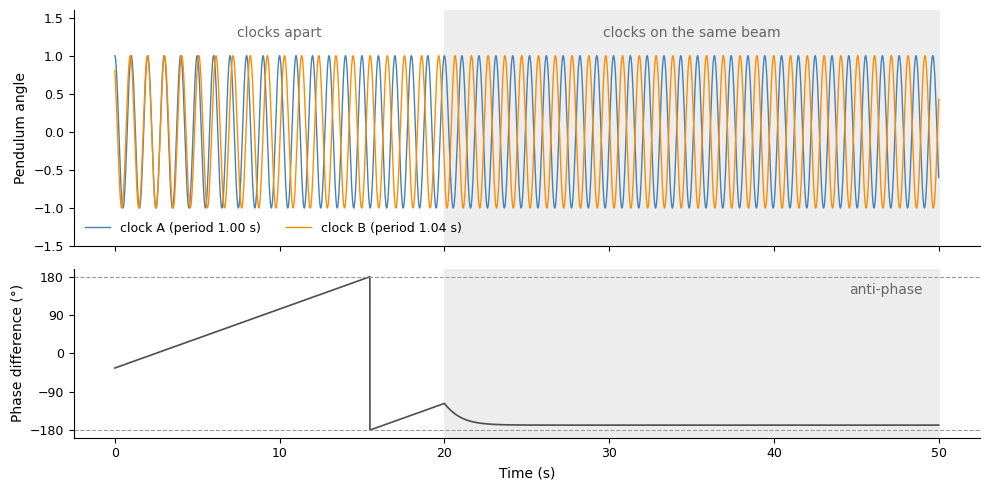

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Two phase oscillators with slightly different natural periods (1.00 s and 1.04 s).
# For the first 20 s they are isolated; then a weak coupling through a shared
# support pulls them towards anti-phase, as Huygens observed.
dt = 0.005
t = np.arange(0, 50, dt)
w1, w2 = 2 * np.pi / 1.00, 2 * np.pi / 1.04
K = 0.6                      # coupling strength, switched on at t = 20 s
th1, th2 = 0.0, 0.6          # initial phases
a1, a2, diff = [], [], []
for tt in t:
    k = K if tt >= 20 else 0.0
    # coupling towards anti-phase: each oscillator is pushed away from the other
    d1 = w1 - k * np.sin(th1 - th2 + np.pi)
    d2 = w2 - k * np.sin(th2 - th1 + np.pi)
    th1 += d1 * dt
    th2 += d2 * dt
    a1.append(np.cos(th1)); a2.append(np.cos(th2))
    diff.append(((th1 - th2 + np.pi) % (2 * np.pi) - np.pi) / np.pi * 180)
a1, a2, diff = map(np.asarray, (a1, a2, diff))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                               gridspec_kw={"height_ratios": [1.4, 1]})
ax1.plot(t, a1, color="steelblue", linewidth=1, label="clock A (period 1.00 s)")
ax1.plot(t, a2, color="darkorange", linewidth=1, label="clock B (period 1.04 s)")
ax1.axvspan(20, 50, color="0.93", zorder=0)
ax1.text(35, 1.25, "clocks on the same beam", ha="center", color="0.4")
ax1.text(10, 1.25, "clocks apart", ha="center", color="0.4")
ax1.set_ylim(-1.5, 1.6)
ax1.set_ylabel("Pendulum angle")
ax1.legend(loc="lower left", ncol=2, frameon=False)
ax2.plot(t, diff, color="0.3", linewidth=1.2)
ax2.axvspan(20, 50, color="0.93", zorder=0)
ax2.axhline(180, color="0.6", linestyle="--", linewidth=0.8)
ax2.axhline(-180, color="0.6", linestyle="--", linewidth=0.8)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.set_ylabel("Phase difference (°)")
ax2.set_xlabel("Time (s)")
ax2.text(49, 165, "anti-phase", ha="right", va="top", color="0.4")
plt.tight_layout()
plt.show()


*Figure: A simulation of Huygens's clocks. Two pendulums with periods of 1.00 and 1.04 s drift apart while isolated; their phase difference winds round and round. From 20 s they are weakly coupled through a shared support, and within a few swings they lock into anti-phase, swinging in mirror image.*

### Measuring entrainment

You can measure your own entrainment with the [Tap along](https://fourms.github.io/sensingsoundandmusic/apps/tap-sync/) app, which scores the mean and spread of your tap timing against a click at any tempo. Most people find that their taps land slightly before the click, by a few tens of milliseconds, which shows that they are predicting the beat rather than reacting to it; the section on producing rhythm in [the body](the-body.ipynb) explains why. Entrainment can also be read from the whole body. In a [motion capture](https://en.wikipedia.org/wiki/Motion_capture) study of people moving to grooves whose beat markers had been shifted by a few tens of milliseconds, the listeners' movements followed the shifts, without the listeners noticing that anything had changed {cite:p}`Danielsen2015`.

### Interpersonal synchrony and joint action

Much of this chapter focuses on one person locking attention and movement to an external pulse. Making music together adds coordination between people: ensembles, choirs, and dance partners stabilise a shared tempo, align their movements, and predict each other's timing. The mechanism is the entrainment described above, now with people coupling to each other as well as to the music. The empirical side of such joint action, from ensemble playing and dance to claims about social bonding, is taken up in [the body](the-body.ipynb).

```{exercise} Spontaneous clapping in a group
:label: exercise-spontaneous-clapping

Do this in class or with a few friends:

- Everyone starts clapping at their own comfortable rate, without looking at each other.
- Keep going for about a minute and listen to what happens.
- Try it again with everyone deliberately starting at very different rates.

Reflect: Did the clapping fall into a common pulse, and how long did that take? Was the shared tempo faster or slower than most people's own rate? Did the common pulse later break up again? The drift into step is entrainment between people, and applause at a concert does the same thing, self-organising into rhythmic clapping and dissolving again as people speed up {cite:p}`Neda2000`.
```

## Metre

[Metre](https://en.wikipedia.org/wiki/Metre_(music)) provides a *hierarchical framework* for the organisation of rhythm, such as 3/4 or 4/4 metres in music. A metric system typically includes a nested system of pulses at several periodicities, from fast subdivisions to slower bar lengths:

- **Beat** **(pulse/tactus)**: the fundamental beat we tend to synchronise or entrain to (e.g. the 1–2–3–4 in a 4/4 metre)
- **Division levels**: subdivisions of the beat (e.g. 8th, 16th, and 32nd notes)
- **Multiple levels**: slower groupings of the beat (e.g. half-notes and bar-lengths)

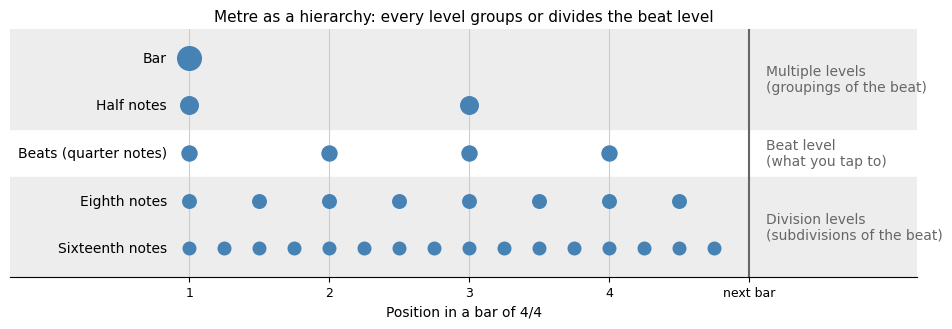

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

levels = [("Bar", 1), ("Half notes", 2), ("Beats (quarter notes)", 4),
          ("Eighth notes", 8), ("Sixteenth notes", 16)]

fig, ax = plt.subplots(figsize=(10, 3.4))
n_levels = len(levels)
ax.axhspan(2.5, 4.6, color="0.93", zorder=0)
ax.axhspan(-0.6, 1.5, color="0.93", zorder=0)
for row, (name, n) in enumerate(levels):
    y = n_levels - 1 - row
    x = np.arange(n) / n
    ax.scatter(x, np.full(n, y), s=260 / (row + 1) + 30, color="steelblue", zorder=3)
    ax.text(-0.04, y, name, ha="right", va="center")
for x in np.arange(0, 1.001, 0.25):
    ax.axvline(x, color="0.8", linewidth=0.8, zorder=1)
ax.axvline(1.0, color="0.4", linewidth=1.5, zorder=2)
ax.text(1.03, 3.55, "Multiple levels\n(groupings of the beat)", va="center", color="0.4")
ax.text(1.03, 2.0, "Beat level\n(what you tap to)", va="center", color="0.4")
ax.text(1.03, 0.45, "Division levels\n(subdivisions of the beat)", va="center", color="0.4")
ax.set_xlim(-0.32, 1.3)
ax.set_ylim(-0.6, 4.6)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["1", "2", "3", "4", "next bar"])
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("Position in a bar of 4/4")
ax.set_title("Metre as a hierarchy: every level groups or divides the beat level")
plt.tight_layout()
plt.show()


*Figure: One bar of 4/4 seen as a stack of pulse levels. Each dot is a pulse; the beat level in the middle is the one listeners usually tap to.*

In notation, metre is written as a *time signature* at the start of the staff. The lower number gives the note value that counts as one pulse and the upper number how many of them make a bar. Beams then show the grouping: 3/4 and 6/8 both hold six eighth notes, but 3/4 beams them in three pairs and 6/8 in two threes, which is exactly the difference between three beats and two. A signature such as 7/8 has beats of unequal length, here 2+2+3, which the section on asymmetric metre below takes up.

```{image} figures/time-and-rhythm/notation/time-signatures.svg
:alt: One bar each of 2/4, 3/4, 4/4, 6/8, 7/8 grouped 2+2+3, and 5/4, with accents on the beats
:width: 100%
```

*Figure: One bar each of six time signatures on a rhythm staff, drawn to the same scale so that the bars show their relative lengths. The accents mark the beats and the beams show how the pulses are grouped into them.*

### Subdivision

[Subdivisions](https://en.wikipedia.org/wiki/Subdivision_(music)) divide each beat into smaller units. We tend to hear them as subdivisions when their IOI duration is between about 100 and 500 milliseconds. Subdivisions add detail and density, and they often act as stylistic markers (e.g., straight eighths in rock, sixteenths in funk, triplet-based 12/8 in blues).

Drum parts are written on a percussion staff, where the lines and spaces stand for instruments rather than pitches. In the common layout the bass drum sits in the bottom space, the snare in the third space, and the hi-hat above the staff with an x-shaped notehead. The three patterns below differ mainly in their subdivision: eighth notes on the hi-hat in the rock beat, a long–short triplet feel in the 12/8 shuffle, and sixteenths in the funk pattern, while the kick and snare keep their places.

```{image} figures/time-and-rhythm/notation/drum-notation.svg
:alt: Drum kit notation: a rock beat with eighth-note hi-hat, a 12/8 shuffle, and a funk pattern with sixteenth-note hi-hat
:width: 100%
```

*Figure: Three drum patterns on a percussion staff, two bars each, differing in the subdivision of the hi-hat. The bass drum sits in the bottom space, the snare in the third space, and the hi-hat above the staff with an x-shaped notehead. These are the rock, shuffle, and funk presets of the drum machine app.*

The [Drum machine](https://fourms.github.io/sensingsoundandmusic/apps/drum-machine/) app lets you hear this directly: one bar of four beats, each divided into two, three, or four steps, on which you draw kick, snare, and hi-hats. Each hit can be soft, medium, or strong, so the grid can also carry a metric accent, the subject of the next section, and a swing control sets the long–short ratio of each pair of subdivisions.

```{exercise} Optional: the same beats, three subdivisions
:label: exercise-drum-machine-subdivision

Open the [Drum machine](https://fourms.github.io/sensingsoundandmusic/apps/drum-machine/) app.

- Start with the rock preset and switch the subdivision to sixteenths and then to triplets. The kick and snare keep their places; what changes?
- Put a hi-hat on every step at each of the three subdivisions and listen at 80, 120, and 160 BPM. At which tempo do the sixteenths stop sounding like separate events and start sounding like a texture?
- Switch on the click on every beat, clear the pattern, and add hits only between the beats. Can you still hear where the beats are?
- Choose the metric accent preset, a hi-hat on every sixteenth with beat 1 strong, the other beats medium, and the rest soft. Then flatten everything to medium. What did the accents tell you that the timing alone does not?

Reflect: Why does the chapter give the subdivision range as roughly 100–500 ms rather than as a range of tempi?
```

### Metric accent

Western music theory traditionally frames metre as a pattern of strong and weak accented beats (e.g., ONE-two-THREE-four in 4/4), with accents thought to align where metrical levels overlap. In practice, this is not always how music is felt or performed. Many groove-based styles emphasise *off-beat positions*. In popular genres such as rock, soul, and R&B, the snare backbeats on 2 and 4 can feel more salient than beat 1. In reggae, the offbeats on the "ands" may dominate more than the downbeats. Metrical accents, then, are not fixed; practice and cultural convention can redefine them.

### Metre as entrainment

Metre can be thought of as entrainment applied to listening. Once a listener has locked on to a beat, attention rises and falls with it, peaking where the next beat is due and dipping in between. It does so at several levels at once, for the subdivision, the beat, and the bar. In this view metre is not a grid printed on the page but a pattern of expectation in the listener, and a metrical accent is simply an event that arrives when attention is at a peak. This is the *dynamic attending* theory, and the figure below shows the idea.

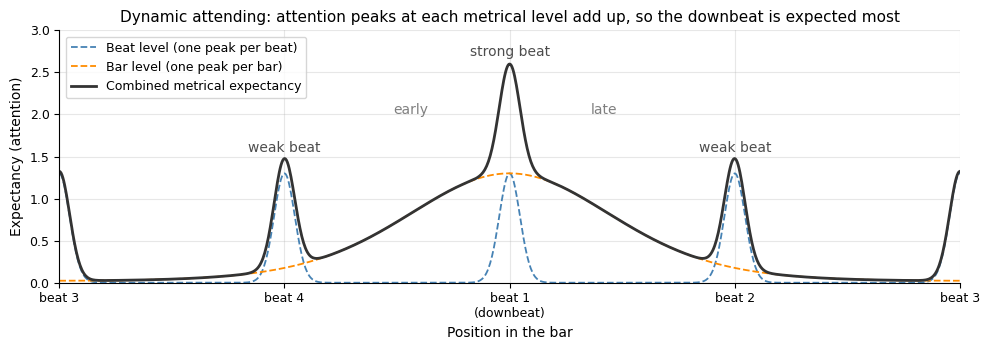

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

phi = np.linspace(-0.5, 0.5, 1000)

def attention(period, width):
    """Periodic peaks of attention (a von Mises pulse train) with one peak per period."""
    return np.exp(width * (np.cos(2 * np.pi * phi / period) - 1))

beat = 1.3 * attention(0.25, 12)      # one peak per beat
bar = 1.3 * attention(1.0, 2)         # one broad peak per bar
mixture = beat + bar

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(phi, beat, color="steelblue", linestyle="--", linewidth=1.3, label="Beat level (one peak per beat)")
ax.plot(phi, bar, color="darkorange", linestyle="--", linewidth=1.3, label="Bar level (one peak per bar)")
ax.plot(phi, mixture, color="0.2", linewidth=2, label="Combined metrical expectancy")
ax.text(0, 2.7, "strong beat", ha="center", color="0.3")
for x in (-0.25, 0.25):
    ax.text(x, 1.55, "weak beat", ha="center", color="0.3")
ax.text(-0.09, 2.0, "early", ha="right", color="0.5")
ax.text(0.09, 2.0, "late", ha="left", color="0.5")
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, 3.0)
ax.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
ax.set_xticklabels(["beat 3", "beat 4", "beat 1\n(downbeat)", "beat 2", "beat 3"])
ax.set_xlabel("Position in the bar")
ax.set_ylabel("Expectancy (attention)")
ax.set_title("Dynamic attending: attention peaks at each metrical level add up, so the downbeat is expected most")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*Figure: Two levels of periodic attention and their sum. An event landing inside a tall peak is heard as metrically accented; one landing on a slope is heard as early or late. Schematic, after {cite:t}`Large2002`.*

Think of metrical accent strength as the *height and narrowness of an attention peak*. Stronger regularity and clearer cueing tighten the window for "on-time", while looser surfaces widen it without losing the beat. At RITMO, we have done EEG studies that show how the brain prepares its response before an expected beat arrives, both for strictly periodic rhythms and for irregular patterns that are learnable {cite:p}`Solli2025`.

### Asymmetric metre

Not all metres divide evenly into twos (binary) and threes (tertiary). *Asymmetric metres* (such as 5/8 or 7/8) have beats of different durations, organised into uneven groupings of equal subdivisions, like 3+2 or 2+2+3. They are common in Balkan, Middle Eastern, and contemporary art-music traditions.

Performers often feel such metres as cycles of unequal steps rather than a uniform grid. The asymmetry can produce a sense of lilt or forward drive distinct from even metres.

The [Metre explorer](https://fourms.github.io/sensingsoundandmusic/apps/metre-explorer/) app lets you hear and see this. A cycle of pulses is grouped into beats, from 2/4 to 11/8 and any grouping you type in, drawn as a circle and as a line whose beat lengths show their durations.

```{exercise} Optional: equal and unequal beats
:label: exercise-metre-explorer

Open the [Metre explorer](https://fourms.github.io/sensingsoundandmusic/apps/metre-explorer/) app.

- Play 3/4 and 6/8 at the same pulse rate. Both have six pulses; what makes them different?
- Play 7/8 as 2+2+3, then 3+2+2, then 2+3+2. Where does the long beat sit in each, and how does the cycle feel different?
- Choose 2+2+3, switch off the beat clicks after four cycles, and keep counting. Do you keep the limp or drift back to equal beats?
- Type a grouping of your own with more than ten pulses and raise the tempo until you stop counting pulses and hear beats instead.

Reflect: In which of these metres is the beat level isochronous, and what would music software that assumes equal beats make of the others?
```

Asymmetric metres are one corner of a much larger world of rhythmic patterns that do not fit a grid of equal beats and binary subdivisions. In Norwegian [telespringar](https://en.wikipedia.org/wiki/Springar), for instance, the three beats of the bar are long, medium, and short, a case the chapter returns to at the end.

:::{note} Dig deeper: rhythmic patterns beyond the even grid
:class: dropdown
Western notation makes two assumptions that are easy to mistake for facts about rhythm: the beats of a bar are equal, and each beat divides into twos or threes. Many traditions organise time differently, and each of them tells us something about what listeners can entrain to.

**Additive metres and [aksak](https://en.wikipedia.org/wiki/Aksak).** In Bulgarian, Macedonian, Greek, and Turkish dance music, a bar is built by adding short (2) and long (3) units: 7/8 as 2+2+3 (*rachenitsa*), 9/8 as 2+2+2+3 (*daichovo*), 11/8 as 2+2+3+2+2 (*kopanitsa*), and so on up to cycles of 25 pulses in some Turkish *usul*. The ethnomusicologist Constantin Brăiloiu called this family *aksak*, Turkish for "limping". The important perceptual point is that dancers and musicians feel the long and short units as *beats*, not as groupings of fast pulses. The beat level itself is non-isochronous, with the long beat one and a half times the short one, and people entrain to it without difficulty. {cite:t}`London2012` argues that such metres are well formed precisely because the unequal beats are "maximally even": the long beats are spread out as far apart as the cycle allows.

**Timelines and bell patterns.** Much West African and Afro-diasporic music is organised around a short repeating *timeline*, usually played on a bell or by clapping, against which everything else is heard. The 12-pulse standard pattern (x.x.xx.x.x.x, which has the same interval structure as the Western diatonic scale) and the 16-pulse *son clave* (x..x..x...x.x...) are the best-known examples, and the *[tresillo](https://en.wikipedia.org/wiki/Tresillo_(rhythm))* 3+3+2 that runs through so much popular music is the first half of the clave. These patterns are asymmetrical within the cycle, yet they sit inside a regular beat: the standard pattern spans four beats of three pulses each, and its strokes fall on and off the beats in a fixed, learnable way. Which strokes count as "on the beat" can differ between musicians and listeners, which is one reason such music sustains several metric hearings at once.

**Euclidean rhythms.** {cite:t}`Toussaint2013` noticed that a striking number of traditional timelines are the patterns you get by spreading *k* onsets as evenly as possible over *n* pulses, which is exactly what Euclid's algorithm for the greatest common divisor computes. E(3,8) is the tresillo, E(5,8) the Cuban *cinquillo*, E(5,12) a common West African and South Indian pattern, and E(7,12) the standard [bell pattern](https://en.wikipedia.org/wiki/Bell_pattern). Maximal evenness turns up again here, now at the level of the pattern rather than the beat, which suggests that a shared perceptual constraint underlies very different musical systems. [Euclidean rhythm](https://en.wikipedia.org/wiki/Euclidean_rhythm) generators are now a standard module in [drum machines](https://en.wikipedia.org/wiki/Drum_machine) and modular synthesisers.

**[Tala](https://en.wikipedia.org/wiki/Tala_(music)).** North and South Indian classical music organises time in cycles called *tala* that can be additive at the beat level as well: *jhaptal* is 2+3+2+3 (10 beats), *rupak* 3+2+2 (7), and *tintal* 4+4+4+4 (16). The first beat of the cycle, *sam*, is the reference point that soloist and drummer converge on, and cycles can be long enough (and tempos slow enough) that keeping the cycle is a skill in itself. Karnatic *konnakol*, the spoken syllable system for drumming, lets performers subdivide a beat into fives, sevens, or nines as fluently as Western musicians handle twos and threes.

**Non-isochronous subdivision.** The unevenness can also sit below the beat. Jazz swing is the familiar case, but it is not the only one. In Malian jembe music the ternary subdivision of a beat is systematically uneven, with the three subpulses taking roughly 40, 30, and 30 percent of the beat rather than a third each, stable across performers and tempos {cite:p}`Polak2014`. Like the springar's unequal beats, this is a timing *norm* rather than an expressive deviation from a grid. Ensembles play these uneven subdivisions as precisely as even ones {cite:p}`Polak2016`, and the way the drummers adapt to each other is spread across musical roles in a pattern that simulations show to be close to optimal for staying together {cite:p}`Jacoby2021`. Rainer Polak, who leads this research at RITMO, is extending it to the dancers in the DjembeDance project.

**Why this matters for perception.** These systems show that entrainment does not require equal beats, only a repeating cycle whose parts are predictable. What varies between traditions is which level carries the unevenness, the subdivision, the beat, or the pattern, and what listeners learn to treat as the reference. Tapping experiments with musicians in Mali, Bulgaria, and Germany make the point directly: everyone shares the simple 1:1 and 2:1 rhythmic prototypes, but prototypes with ratios such as 3:2 and 4:3 appear only in the cultures whose music uses them {cite:p}`Polak2018`. Analysis software that quantises everything to a regular grid, or beat trackers trained on isochronous popular music, will misread all of the patterns above, which is a recurring theme when we reach [machine listening](machine-listening.ipynb).
:::

## Microrhythm

*Microrhythm* refers to the fine-scale timing and shaping of events around our subjective reference structures (beat, subdivision). Unlike beat- and subdivision-level rhythms, microrhythm concerns variations in timing at a scale below 100 ms. The ethnomusicologist Charles Keil called such small timing and tuning discrepancies between players *participatory discrepancies*, arguing that they are what give music its characteristic feel. 

At RITMO, many researchers have worked on understanding more about how microrhythm influences music perception and cognition. This has been spearheaded by Anne Danielsen's work on funk and groove, beginning with her analyses of James Brown and Parliament {cite:p}`Danielsen2006` and continuing  with more fundamental research on microrhythm {cite:p}`Danielsen2024`.

### Asynchrony and non-isochrony
In terms of timing, we can speak of two related but different forms of microrhythm: *asynchrony* and *non-isochrony*. Asynchrony refers to the way musicians can play in a more synchronised ("on-beat") or asynchronous way (early/"pushed" or late/"laid-back") relative to one another. Non-isochrony relates to how they might skew the durational ratio of metrical subdivision levels (e.g., 8th or 16th notes) to varying degrees, from isochronous ("straight") to non-isochronous ("swung").

Microrhythm can encompass both expressive moment-to-moment nuance and systematic patterns that recur across a piece or style. In many performance traditions, those systematic patterns are the *norm*, rather than "*deviations*" from an ideal of perfect metronomic or isochronous timing.

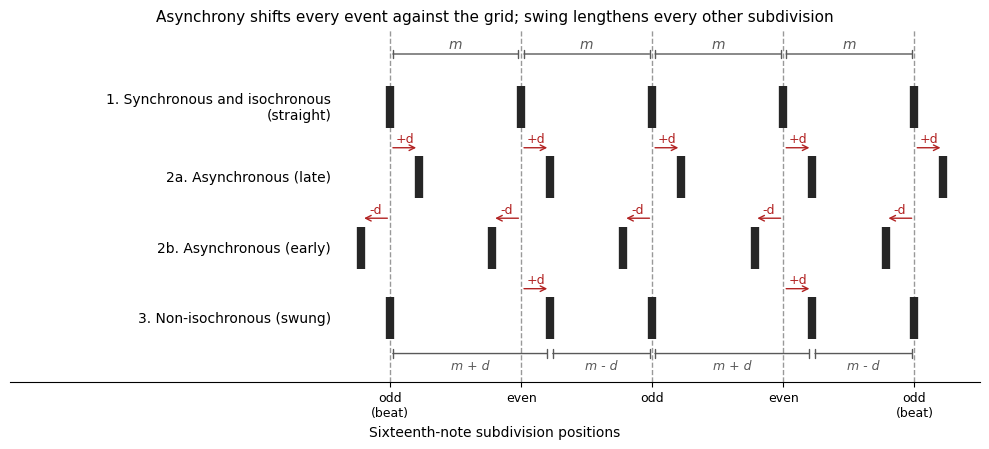

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

m = 1.0                                   # mean subdivision interval
d = 0.22                                  # displacement
grid = np.arange(5) * m
rows = [
    ("1. Synchronous and isochronous\n(straight)", grid, None),
    ("2a. Asynchronous (late)", grid + d, "+d"),
    ("2b. Asynchronous (early)", grid - d, "-d"),
    ("3. Non-isochronous (swung)", grid + np.array([0, d, 0, d, 0]), "+d"),
]

fig, ax = plt.subplots(figsize=(10, 4.6))
for x in grid:
    ax.axvline(x, color="0.6", linestyle="--", linewidth=1, zorder=0)
for r, (label, times, tag) in enumerate(rows):
    y = len(rows) - 1 - r
    ax.vlines(times, y - 0.3, y + 0.3, color="0.15", linewidth=6)
    ax.text(-0.45, y, label, ha="right", va="center")
    if tag:
        for g, x in zip(grid, times):
            if abs(x - g) > 1e-9:
                ax.annotate("", xy=(x, y + 0.42), xytext=(g, y + 0.42),
                            arrowprops=dict(arrowstyle="->", color="firebrick"))
                ax.text((x + g) / 2, y + 0.5, tag, ha="center", color="firebrick", fontsize=9)
for k in range(4):                                                  # m brackets on top
    ax.annotate("", xy=(grid[k], 3.75), xytext=(grid[k + 1], 3.75),
                arrowprops=dict(arrowstyle="|-|", color="0.35", mutation_scale=3))
    ax.text(grid[k] + m / 2, 3.83, "m", ha="center", color="0.35", style="italic")
for k, label in zip(range(4), ["m + d", "m - d", "m + d", "m - d"]):   # swung durations
    x0 = rows[3][1][k]
    x1 = rows[3][1][k + 1]
    ax.annotate("", xy=(x0, -0.5), xytext=(x1, -0.5),
                arrowprops=dict(arrowstyle="|-|", color="0.35", mutation_scale=3))
    ax.text((x0 + x1) / 2, -0.72, label, ha="center", color="0.35", style="italic", fontsize=9)
ax.set_xlim(-2.9, 4.5)
ax.set_ylim(-0.9, 4.1)
ax.set_yticks([])
ax.set_xticks(grid)
ax.set_xticklabels(["odd\n(beat)", "even", "odd", "even", "odd\n(beat)"])
ax.set_xlabel("Sixteenth-note subdivision positions")
ax.spines["left"].set_visible(False)
ax.set_title("Asynchrony shifts every event against the grid; swing lengthens every other subdivision")
plt.tight_layout()
plt.show()


*Figure: The reference grid (dashed) has a mean subdivision interval m. Asynchrony displaces events by d in one direction; swing displaces only the even-numbered subdivisions, producing alternating long and short durations. Redrawn after {cite:t}`Camara2025`, Figure 1.*

:::{note} Dig deeper: quantifying asynchrony and swing
:class: dropdown
Asynchrony is measured as *onset displacement* (*d*): how many milliseconds early (negative) or late (positive) an onset falls relative to a timing reference grid. Swing is quantified in two ways: as the absolute onset displacement (*d*) from the grid position of an even-numbered/off-beat subdivision event, in milliseconds; or as the *swing ratio* (*R*) between the duration of an odd-numbered subdivision event (*m* + *d*) and the subsequent even subdivision (*m* − *d*), where *m* is the mean inter-onset-interval (IOI) of the subdivision level:

$$R = \frac{m + d}{m - d}$$

A straight pair gives 1:1 and a triplet-based long–short pair 2:1; the result may also be written as a decimal, such as 1.5.
:::

```{exercise} Optional: move the onsets
:label: exercise-microtiming

Open the [Microtiming](https://fourms.github.io/sensingsoundandmusic/apps/microtiming/) app and press Start.

- Push the snare 20 ms late with its slider and flip between grid and shifted. Describe the difference in a word or two, then try 40 ms and 60 ms. Where does laid-back become late?
- Quantise, then push the kick 20 ms late instead. Is the effect the same as with the snare? The asynchrony between them is the same size.
- Quantise, then drag only the hi-hat's off-beat eighths late until the swing ratio reads about 1.5:1, then 2:1. Compare with the triplet grid of the drum machine.
- Apply random jitter of ±10 ms. Can you hear that anything changed? Then apply it twice.

Reflect: The onset displacement *d* is one number per onset. What does hearing the grid and the shifted version back to back tell you that the numbers cannot?
```

### Beat delay / anticipation

Musicians sometimes play *behind or ahead of the beat* in a *systematic* way, whether consciously or not. In rock and soul styles, snare strokes on beats 2 and 4 of a 4/4 metre are often said to be delayed, and in funk, downbeats are said to regularly anticipate "One". What counts as "late" or "early" always depends on a reference in the given context, whether kick, snare, or the overall grid.

Different degrees of *beat delay/anticipation* are said to convey different *feels*. Delayed (late) backbeats in groove styles are often described as "*laid-back*": a relaxed feel when only slightly delayed, but a "heavy" or "dragging" feel if delayed too much. Anticipated (early) beats are described as "*on-top/pushed*", which at lower magnitudes can sound "snappy" and "driving", but too much may sound "nervous" or "rushing".

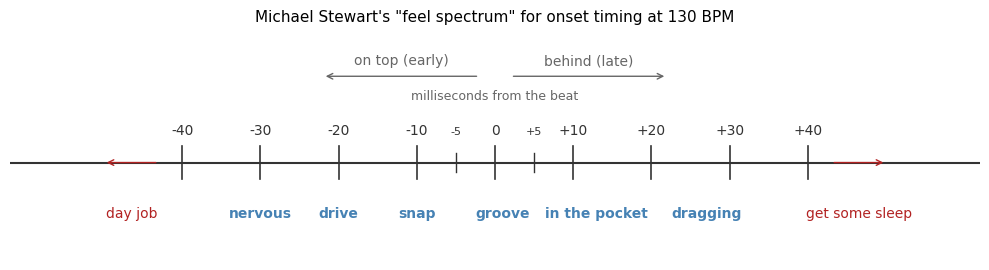

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axhline(0, color="0.2", linewidth=1.5)
for x in range(-40, 41, 10):
    ax.plot([x, x], [-0.12, 0.12], color="0.2", linewidth=1.2)
    ax.text(x, 0.2, f"{x:+d}" if x else "0", ha="center", color="0.2")
for x in (-5, 5):
    ax.plot([x, x], [-0.07, 0.07], color="0.2", linewidth=1)
    ax.text(x, 0.2, f"{x:+d}", ha="center", color="0.2", fontsize=8)
labels = [(-30, "nervous"), (-20, "drive"), (-10, "snap"), (1, "groove"),
          (13, "in the pocket"), (27, "dragging")]
for x, name in labels:
    ax.text(x, -0.32, name, ha="center", va="top", color="steelblue", fontweight="bold")
ax.annotate("", xy=(-50, 0), xytext=(-43, 0), arrowprops=dict(arrowstyle="->", color="firebrick"))
ax.text(-46.5, -0.32, "day job", ha="center", va="top", color="firebrick")
ax.annotate("", xy=(50, 0), xytext=(43, 0), arrowprops=dict(arrowstyle="->", color="firebrick"))
ax.text(46.5, -0.32, "get some sleep", ha="center", va="top", color="firebrick")
ax.annotate("", xy=(-22, 0.62), xytext=(-2, 0.62), arrowprops=dict(arrowstyle="->", color="0.4"))
ax.annotate("", xy=(22, 0.62), xytext=(2, 0.62), arrowprops=dict(arrowstyle="->", color="0.4"))
ax.text(-12, 0.7, "on top (early)", ha="center", color="0.4")
ax.text(12, 0.7, "behind (late)", ha="center", color="0.4")
ax.text(0, 0.45, "milliseconds from the beat", ha="center", color="0.4", fontsize=9)
ax.set_xlim(-62, 62)
ax.set_ylim(-0.7, 0.95)
ax.set_axis_off()
ax.set_title("Michael Stewart's \"feel spectrum\" for onset timing at 130 BPM")
plt.tight_layout()
plt.show()


*Figure: A producer's rule of thumb for how far ahead of or behind the beat to place events, and what each amount feels like. Redrawn after Stewart, in {cite:t}`Progler1995`.*

### Swing

Subdivision notes need not be isochronous (equal), as they are in a straight-8ths hi-hat pattern in rock. [Swing](https://en.wikipedia.org/wiki/Swing_(jazz_performance_style)), a form of non-isochrony (non-equal durations), describes systematic long–short patterns at the subdivision level.

In jazz, musicians typically do not swing at a perfectly mechanical "triplet swing" ratio of 2:1. Instead, swing ratios in performance can range from close to 1:1 (straight) all the way up to 3:1 (dotted swing) and beyond, depending on tempo, sub-genre, personal style, and other factors. In funk and hip-hop, by contrast, sixteenth notes tend to be swung more subtly (e.g., 1.2:1) unless played in explicit funk-shuffle styles (closer to 2:1, triplet). Swing also depends on tempo. In a study of a samba groove performed at several tempos, the uneven sixteenth notes became more even as the tempo increased, so the same groove has a different swing ratio when played slow and fast {cite:p}`Haugen2020`.

Different swing ratios are thought to impart different degrees of "motional energy" to rhythms. Rhythms with lower swing ratios (closer to 1:1) are described as more "continuous", "driving", or "propulsive", whereas higher swing ratios (up to 2:1 and beyond) tend to give "bounce" or "choppiness", often accentuating the downbeats and on-beats of the metre.

### Perceptual thresholds of microrhythm

Recall from [psychoacoustics](psychoacoustics.ipynb) that the just-noticeable difference (JND) is the smallest change a listener can reliably detect. Microrhythm has its own JNDs, and they are surprisingly small: differences of a few tens of milliseconds are enough to change how a groove feels. How small depends on the sounds involved (sharp drum attacks are easier to judge than blended sustained tones), on tempo and note density, and on musical training.

:::{note} Dig deeper: measured JND thresholds
:class: dropdown
Asynchrony JNDs depend strongly on instrument attacks and texture. With overlapping, sustained, or blended tones (e.g., piano, strings, winds, voices), listeners typically need onsets to differ by roughly 20–50 ms before they hear them as asynchronous. In groove contexts, which often involve sharper, more transient sounds (e.g., drums, picked bass), smaller onset displacements can be detected, around 10–20 ms for trained musicians.

For swing, non-musicians tend to need around 30 ms of displacement (a ratio of about 1.4) to hear rhythms as non-straight, while trained musicians can detect swing at around 10 ms displacement (about 1.1–1.2).

For more on JNDs of microrhythm in music, see {cite:p}`Camara2025`.
:::

## Groove

[Groove](https://en.wikipedia.org/wiki/Groove_(music)) can be understood in many ways: as a rhythmic pattern, as a way of playing, and as the pleasurable urge to move that such playing produces. The word has travelled from an LP record's physical groove to jazz slang and has later also become a research concept {cite:p}`Camara2019`. Here we focus on groove as "pattern" and as "performance approach", with an eye on time and rhythm.

As a pattern, a groove can be defined simply as a persistently repeated rhythm, often spanning one or two bars, whose events establish a clear beat and a characteristic subdivision layer. The beat may be externalised (e.g., a kick/snare backbeat in 4/4) or implied by cyclic "isoperiodic" figures that recur predictably. Style identity often hinges on the *basic unit* (the smallest repeating chunk) and its *density referent* (the shortest subdivision practically used).

As performance, a groove is the coordinated realisation of that basic unit across parts (e.g., drums, bass, guitar/keys, vocals). Players distribute roles: some layers reinforce the beat (e.g., kicks on beats 1 and 3, snare on 2 and 4), while others supply tension by playing on off-beat subdivisions (e.g., bass accentuating the "2-and"). Grooves often balance stability (an easily entrainable pulse) with off-beat devices that add interest and complexity, such as syncopation and cross-/counter-rhythm (see below).

### Syncopation

[Syncopation](https://en.wikipedia.org/wiki/Syncopation) is often described as a local contradiction of a metrical expectation: a note on a weak-position accent, a tie across a strong beat, or the omission of a strong beat followed by sound on a weak one. In 4/4, common cases include stressing the "and" of 2 or 4, tying into 1, or placing a salient event on 3-and while 3 itself is silent. Because the beat is usually firmly established in groove styles, such contradictions tend to add *tension* without destabilising the metre. 

Listening experiments confirm the link to groove: adding syncopation to plain synthesised patterns increases how much listeners want to move, up to a point beyond which the pattern becomes too irregular to follow {cite:p}`Sioros2014`.

### Counter-/cross-rhythm

When syncopated events recur *systematically* within the basic unit, they can form larger-scale, patterned off-beat groupings that suggest alternative periodicities to the main beat.

[Cross-rhythm](https://en.wikipedia.org/wiki/Cross-beat) (often called "[polyrhythm](https://en.wikipedia.org/wiki/Polyrhythm)") occurs when these groupings display a systematic overlap of rhythmic streams whose periodicities (i.e., "metrical levels") are non-integer multiples. Typical examples in 4/4 are two evenly spaced events over three beats (2:3 cross-rhythms) or four events over three or six beats (4:3 or 4:6 cross-rhythms). The regular pattern of overlapping accents contradicts the beats of the prevailing metre, challenging it and creating greater metrical ambiguity, to the point where one might hear the pulse as either binary or triplet.

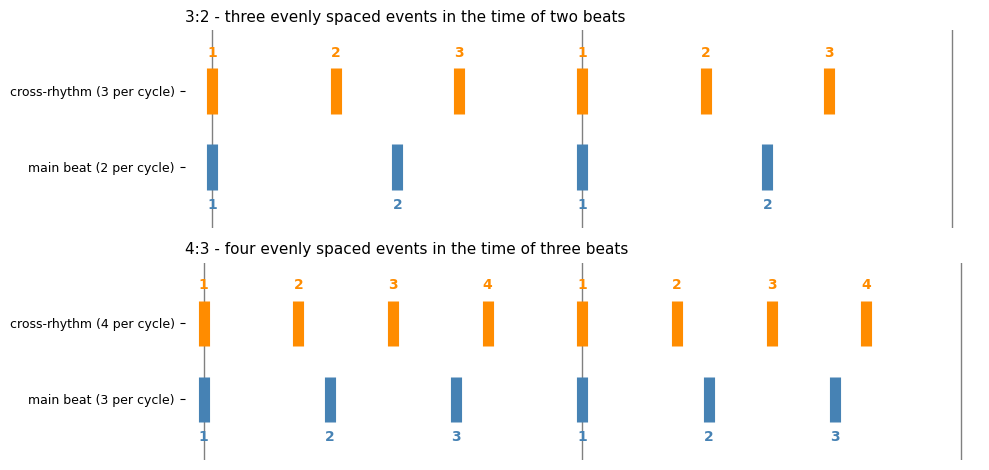

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def draw(ax, cycle, n_main, n_cross, repeats, title):
    total = cycle * repeats
    main = np.arange(n_main * repeats) * cycle / n_main
    cross = np.arange(n_cross * repeats) * cycle / n_cross
    for r in range(repeats + 1):
        ax.axvline(r * cycle, color="0.5", linewidth=1)
    ax.vlines(main, 0.7, 1.3, color="steelblue", linewidth=8)
    ax.vlines(cross, 1.7, 2.3, color="darkorange", linewidth=8)
    for k, x in enumerate(main):
        ax.text(x, 0.45, str(k % n_main + 1), ha="center", color="steelblue", fontweight="bold")
    for k, x in enumerate(cross):
        ax.text(x, 2.45, str(k % n_cross + 1), ha="center", color="darkorange", fontweight="bold")
    ax.set_xlim(-0.15, total + 0.15)
    ax.set_ylim(0.2, 2.8)
    ax.set_yticks([1, 2])
    ax.set_yticklabels([f"main beat ({n_main} per cycle)", f"cross-rhythm ({n_cross} per cycle)"])
    ax.set_xticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.set_title(title, loc="left")

fig, axes = plt.subplots(2, 1, figsize=(10, 4.8))
draw(axes[0], cycle=2, n_main=2, n_cross=3, repeats=2, title="3:2 - three evenly spaced events in the time of two beats")
draw(axes[1], cycle=3, n_main=3, n_cross=4, repeats=2, title="4:3 - four evenly spaced events in the time of three beats")
plt.tight_layout()
plt.show()


*Figure: Cross-rhythms as two simultaneous pulse streams. The two streams meet only at the start of each cycle (vertical lines), which is why they blur the sense of a single pulse.*

In most groove styles, though, such overlapping rhythms are usually *bounded*. They tend to span less than a bar and to coincide again with beat-confirming positions of the metre before repeating. This generates less metrical ambiguity without fundamentally challenging the main pulse. Typical counter-rhythmic groupings in 4/4 are 3+3+2 over eight eighth notes, or 3+3+3+3+2+2 over sixteen sixteenths; listeners may hear secondary "pulses" riding on top of the main metre. The 3+3+2 grouping is the *tresillo* introduced in the note on rhythmic patterns earlier in this chapter.

```{image} figures/time-and-rhythm/notation/rhythm-patterns.svg
:alt: Four rhythmic patterns in notation: tresillo, 3+3+3+3+2+2, cinquillo, and son clave
:width: 100%
```

*Figure: Four counter-rhythmic patterns written in 4/4. The tresillo and the 3+3+3+3+2+2 grouping are the two mentioned above; the cinquillo and the two-bar son clave are their Afro-Cuban relatives from the note on rhythmic patterns.*

```{exercise} Two hands, two pulses
:label: exercise-polyrhythm-hands

Play a cross-rhythm with your own two hands on a table.

- Start with 3 against 2. Count a slow cycle of six pulses. The right hand taps on 1, 3, and 5; the left hand on 1 and 4. Put together, the two hands make one rhythm: both, right, left, right. Say "hot cup of tea" with one word per tap and it falls into place.
- Once it is steady, speed up. At some point the composite rhythm stops being a little tune and becomes two streams, one in each hand. Note roughly the tempo at which that happens.
- Swap the hands and start again. Is it as easy the other way round?
- Now 4 against 3 over a cycle of twelve pulses: right on 1, 4, 7, and 10; left on 1, 5, and 9. The composite is both, right, left, right, left, right, and "what atrocious weather" gives one syllable per tap.
- Accent one hand while keeping both going, then accent the other. Listen to which hand you hear as the beat and which as the cross-rhythm.

Reflect: When both hands were going, which of them did you feel as the pulse, and did that change with the accent? Why does the composite rhythm help at slow tempi but get in the way at fast ones? How does this relate to the two pulse streams in the figure above?
```

## A room's tempo

Everything in this chapter so far has run on musical time scales: onsets tens of milliseconds apart, beats around half a second, phrases lasting a few seconds. However, periodicity can be found everywhere in the world.

Think about the rhythmic nature of many machines. Motors, refrigerators, and ventilation systems all run with different types of duty cycles. A refrigerator typically turns on and off a couple of times per hour. A dishwasher adds a single long phrase with its own internal wash, rinse, and dry structure on top of that pulse.

```{exercise} Optional: find your room's tempo
:label: exercise-room-tempo

Record 10–15 minutes in a room with one or more cycling machines (a kitchen is a good place!).

- Plot the level over time (or just note the clock times when the machine
  switches on and off).
- Estimate the period and the duty cycle: how long is one on–off cycle, and
  what fraction of it is "on"?
- At what period does something stop feeling like *rhythm* and
  start feeling like *schedule*? Would you notice if a cycle were skipped?
```

## A critical look: when beats refuse to be equal

Most rhythm research, and most music software, quietly assumes that the beats of a metre are isochronous. For rock, pop, and EDM the assumption mostly holds. Not so much for folk and experimental music.

- **The claim** under test is that metre rests on equal beats, so that any unevenness is expressive deviation from an underlying regular grid.
- **The evidence** says otherwise for Norwegian folk music. Measurements of telespringar performances show bars divided into stable long–medium–short beats, in proportions that remain consistent across tunes and performers {cite:p}`Haugen2016`.
- **The method** combined audio analysis with motion capture of a fiddler and a dancing couple. The fiddler's foot stamping and the dancers' vertical motion followed the same non-isochronous pattern, suggesting a shared bodily reference structure rather than sloppy timing.
- **The limits** are a small number of performers, one regional style, and proportions that vary somewhat between players and districts. The finding does not overturn metre theory; it shows that the reference grid itself can be uneven and learned.

```{admonition} Chapter summary
:class: tip
This chapter began with time itself: the scales from microseconds to years, the layers of memory that decide which of them we can feel as rhythm, and the gap between clock time and felt time. Rhythm was defined broadly as repetition and narrowly as a pattern of perceived time points, which made the timing of a single sound, its physical onset against its perceptual centre, the first thing to settle. From there the chapter built upwards. The beat and its tempo are rooted in the moving body, as the spontaneous motor tempo shows. Entrainment, the coupling of oscillators, is what lets us move to a beat and to each other. Metre is the hierarchy of subdivisions, beats, and accents that entrainment builds, and its beats need not be equal. Microrhythm then looked below the beat at asynchrony, beat delay, and swing, and at how small a shift listeners can hear, and groove brought pattern and performance together. The room's tempo showed periodicity beyond music, and the telespringar case showed that the reference grid itself can be uneven and learned. Entrainment continues with the body in [the body](the-body.ipynb) and with breathing and heart rate in [physiology](physiology.ipynb), and melody and harmony interact with these timing patterns in [harmony and melody](harmony-and-melody.ipynb).
```

```{admonition} Questions
:class: question
1. Where on the scale of time do a heartbeat, the beat of a song, a phrase, and a fridge's on–off cycle fall, and which of them can be perceived as rhythm in Fraisse's sense?
2. Why can two sounds with the same physical onset be heard at different moments, and what does that mean for musicians who want to sound together?
3. What is the spontaneous motor tempo, and what does its overlap with walking and with preferred musical tempo suggest about musical time?
4. How does the coupled-oscillator account explain why listeners and players fall into step with a beat, and which oscillating processes in a person can entrain to music?
5. How do rhythm and metre differ, and how can a backbeat on 2 and 4 feel stronger than beat 1 without changing the metre?
6. Why does the same kick and snare pattern feel different on an eighth-note, triplet, and sixteenth-note grid?
7. How do asynchrony and swing differ as forms of microrhythm, and how small a displacement can listeners hear?
8. In the telespringar case, what did motion capture add to the audio measurements, and why does the case challenge the assumption of isochronous beats?
```

:::{seealso} Further reading
- **Justin London, *Hearing in Time: Psychological Aspects of Musical Meter* (Oxford University Press)** — how we perceive metre and pulse. https://doi.org/10.1093/acprof:oso/9780199744374.001.0001
- **Anne Danielsen, *Presence and Pleasure: The Funk Grooves of James Brown and Parliament* (Wesleyan University Press)** — the book behind this chapter's funk examples and much of its vocabulary. https://doi.org/10.1353/book.125990
- **Guilherme Schmidt Câmara and Anne Danielsen, "Groove", in *The Oxford Handbook of Critical Concepts in Music Theory* (Oxford University Press)** — where the word comes from and how groove is studied as pattern, performance, and experience. https://doi.org/10.1093/oxfordhb/9780190454746.013.17
- **Henkjan Honing, *Musical Cognition* (Routledge)** — an accessible take on rhythm and timing. https://books.google.com/books/about/Musical_Cognition.html?id=6HUHu0aq_SAC
:::

:::{tip} Explore interactively
- [From pulse to pitch](https://fourms.github.io/sensingsoundandmusic/apps/pulse-to-pitch/) — repeat a click at any rate from 1 to 1000 per second and hear where separate pulses fuse into a tone, with the impulses and their spectrum drawn.
- [Metre explorer](https://fourms.github.io/sensingsoundandmusic/apps/metre-explorer/) — group a cycle of pulses into equal or unequal beats, from 2/4 to 11/8 and beyond, drawn as a circle and a line.
- [Microtiming](https://fourms.github.io/sensingsoundandmusic/apps/microtiming/) — drag every onset of a groove early or late and hear the difference between the grid and the shifted version.
- [Drum machine](https://fourms.github.io/sensingsoundandmusic/apps/drum-machine/) — draw a bar of kick, snare, and hi-hats on an eighth, triplet, or sixteenth grid and hear how subdivision changes the feel.
- [Silent beats](https://fourms.github.io/sensingsoundandmusic/apps/silent-beats/) — silence clicks and events in a looping bar, drop the pulse for whole bars, and rotate a rhythm against the beat.
- [Spontaneous tempo](https://fourms.github.io/sensingsoundandmusic/apps/spontaneous-tempo/) — tap for 20 s with no feedback and read off your spontaneous motor tempo, or watch the intervals live.
- [Tap along](https://fourms.github.io/sensingsoundandmusic/apps/tap-sync/) — tap with a click and see your mean asynchrony, variability, and swing ratio.
- [Ableton Learning Music](https://learningmusic.ableton.com/) — build beats and feel metre interactively.
- [Groove Pizza](https://apps.musedlab.org/groovepizza/) — design and visualise grooves on a circular grid.
:::